# Дискретное преобразование Фурье

## Названия и виды ДПФ
---
При известном представлении во временной области переход в частотную область называется **декомпозицией**, **анализом**, **прямым ДПФ** или просто **ДПФ**. Наоборот, переход к временному представлению сигнала при известном частотном представлении называется **синтезом** или **обратным ДПФ**.

## Обозначения ДПФ
---
Сигналы, представленные во временной области, принято обозначать строчными буквами, например: **x[ ]**, **y[ ]** или **z[ ]**. Те же обозначения, выполненные заглавными буквами, относятся к представлению тех же сигналов в частотной области: **X[ ]**, **Y[ ]** и **Z[ ]**. 

Пусть, например, имеется **N**-точечный сигнал **x[ ]**, представленный во временной области. Его частотное представление будет обозначаться **X[ ]** и включать две составляющие, каждая длиной **(N/2 + 1)** отсчёт:  
- действительную часть **X[ ]**, обозначаемую **Re X[ ]**  
- мнимую часть **X[ ]**, обозначаемую **Im X[ ]**.  

**Re X[ ]** содержит значения амплитуд косинусных сигналов разложения,  
**Im X[ ]** — значения амплитуд синусных сигналов разложения (без учёта нормировки).  

Аналогично представлению сигнала во временной области (**x[0]...x[N-1]**),  
в частотной области используются:  
- **Re X[0]...Re X[N/2]**  
- **Im X[0]...Im X[N/2]**.  

Рекомендуем хорошо запомнить эти обозначения. 

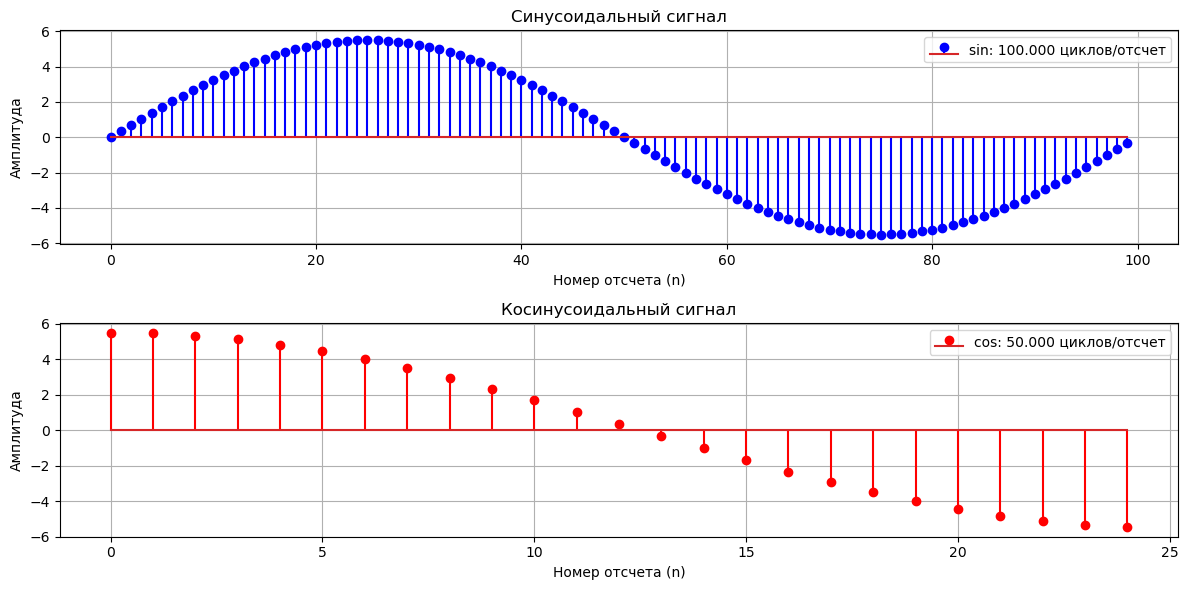

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Получаем текущую директорию ноутбука
import sys
import os
notebook_dir = os.path.dirname(os.path.abspath('beginning_dft.ipynb'))
project_root = os.path.abspath(os.path.join(notebook_dir, '..', '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
try:
    from dsp_lib.signal_generators import gen_sin, gen_cos
except ImportError as e:
    module_path = os.path.join(project_root, 'dsp_lib', 'signal_generators.py')
############################################################################################ 

# Пример использования
if __name__ == "__main__":
    # Параметры сигнала
    S0_AMPLITUDE = 5.5
    S0_FREQUENCY = 100  # количество отсчетов на один период
    S0_PHASE = 0 #np.pi/4   # 45° в радианах
    S0_N_SAMPLES = 100   # Количество отсчетов

    C0_AMPLITUDE = 5.5
    C0_FREQUENCY = 50  # количество отсчетов на один период
    C0_PHASE = 0 #np.pi/4   # 180°/4 = 45° в радианах
    C0_N_SAMPLES = 25   # Количество отсчетов
    
    sin_wave = gen_sin(S0_AMPLITUDE, S0_FREQUENCY, S0_PHASE, S0_N_SAMPLES)
    cos_wave = gen_cos(C0_AMPLITUDE, C0_FREQUENCY, C0_PHASE, C0_N_SAMPLES)

    
    # Визуализация
    n = np.arange(S0_N_SAMPLES)
    # print(sin_wave)
    # print(n)
    plt.figure(figsize=(12, 6))
    
    plt.subplot(2, 1, 1)
    plt.stem(n, sin_wave, 'b-', label=f'sin: {S0_FREQUENCY:.3f} циклов/отсчет')
    plt.title('Синусоидальный сигнал')
    plt.xlabel('Номер отсчета (n)')
    plt.ylabel('Амплитуда')
    plt.grid(True)
    plt.legend()

    n = np.arange(C0_N_SAMPLES)
    plt.subplot(2, 1, 2)
    plt.stem(n, cos_wave, 'r-', label=f'cos: {C0_FREQUENCY:.3f} циклов/отсчет')
    plt.title('Косинусоидальный сигнал')
    plt.xlabel('Номер отсчета (n)')
    plt.ylabel('Амплитуда')
    plt.grid(True)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [2]:
import numpy as np
from bokeh.plotting import figure, show

# библиотека на основе которой были сделаны графики
# https://docs.bokeh.org/en/latest/docs/user_guide/basic/layouts.html
from bokeh.layouts import column
from bokeh.io import output_notebook
# from bokeh.models import Range1d
# Активируем вывод графиков в ноутбук
output_notebook()

# # Параметры сигнала
N = 16  # Число точек
fs = 512  # Частота дискретизации (Гц)
f1 = 64  # Частота синусоиды (Гц)
f2 = 64  # Частота синусоиды (Гц)
f3 = 128  # Частота синусоиды (Гц)
f4 = 4  # Частота синусоиды (Гц)
f5 = 8  # Частота синусоиды (Гц)

f1 = 0  # Частота синусоиды (Гц)
# f2 = 0  # Частота синусоиды (Гц)
f3 = 0  # Частота синусоиды (Гц)
f4 = 0  # Частота синусоиды (Гц)
f5 = 0  # Частота синусоиды (Гц)
amplitude = 1.0  # Амплитуда синусоиды
noise_level = 0.0  # Уровень шума
 
# Генерация временного сигнала (синусоида + шум)
t = np.arange(N) / fs  # Временная ось
signal = amplitude * np.sin(2 * np.pi * f1 * t)  # Чистая синусоида
signal2 = amplitude * np.sin(2 * np.pi * f2 * t + np.pi/1)  # Чистая синусоида
signal3 = amplitude * np.sin(2 * np.pi * f3 * t)  # Чистая синусоида
signal4 = amplitude * np.sin(2 * np.pi * f4 * t)  # Чистая синусоида
signal5 = amplitude * np.sin(2 * np.pi * f5 * t)  # Чистая синусоида
noise = noise_level * np.random.randn(N)  # Гауссов шум


# signal2 = [1,1,0,0,1,1,0,0,1,1,0,0,1,1,0,0]  # Чистая синусоида


XX = signal + noise + signal2 + signal3 + signal4 + signal5  # Исходный сигнал
sinus = amplitude * np.sin(2 * np.pi * f5 * t)  # Чистая синусоида #################################################################


indices = np.arange(N)  # Ось отсчётов

# DFT (прямое преобразование Фурье)
REX = np.zeros(N // 2 + 1)
IMX = np.zeros(N // 2 + 1)

# Печать заголовка таблицы
# print("K   I   IMX[K]".ljust(20) + "XX[I]".ljust(20) + "np.sin(angle)".ljust(20) + "angle(deg)")
# print("-" * 80)

for K in range(N // 2 + 1):
    for I in range(N):
        angle = 2 * np.pi * K * I / N
        REX[K] += XX[I] * np.cos(angle)
        IMX[K] -= XX[I] * np.sin(angle)
        if K == 2:
            # sinus[I] =        np.sin(angle)
            # Форматирование значений для выравнивания
            k_str = f"K = {K}"
            i_str = f"I = {I}"
            imx_str = f"IMX[K] = {IMX[K]:.5f}"
            rex_str = f"REX[K] = {REX[K]:.5f}"
            xx_str = f"XX[I] = {XX[I]:.5f}"
            sin_str = f"np.sin(angle) = {np.sin(angle):.5f}"
            cos_str = f"np.cos(angle) = {np.cos(angle):.5f}"
            # angle_str = f"{(180 * angle / 3.14) % 360:.2f}°"
            angle_str = f"{angle:.2f}"
            
            # Вывод с фиксированной шириной колонок
            print(f"{k_str:<8}{i_str:<8}{imx_str:<20}{rex_str:<20}{xx_str:<20}{sin_str:<25}{cos_str:<25}{angle_str}")
print("Амплитудный и фазовый спектры = " + str(np.sqrt(REX**2 + IMX**2)))
print ("sinus = " + str(sinus))
# Амплитудный и фазовый спектры
amplitude_spectrum = np.sqrt(REX**2 + IMX**2)
phase_spectrum = np.arctan2(IMX, REX)

# Частотная ось
freq = np.linspace(0, fs / 2, N // 2 + 1)

# Создание интерактивных графиков
tools = "pan,box_zoom,wheel_zoom,save,reset,help"

# 1. График временного сигнала по отсчётам
samples_plot = figure(
    title="Входной сигнал (по отсчётам)",
    x_axis_label="Отсчёты",
    y_axis_label="Амплитуда",
    height=300,
    width=800,
    tools=tools,
    toolbar_location="above"
)

samples_plot.circle(indices, XX, size=8, color="green", alpha=0.8, legend_label="XX")
samples_plot.circle(indices, signal2, size=8, color="blue", alpha=0.8, legend_label="signal2")
samples_plot.circle(indices, signal, size=8, color="red", alpha=0.8, legend_label="signal")
samples_plot.circle(indices, sinus, size=8, color="orange", alpha=0.8, legend_label="sinus")
samples_plot.line(indices, XX, line_width=2, color="darkgreen", legend_label="Огибающая")
samples_plot.line(indices, signal2, line_width=2, color="blue", legend_label="Огибающая")
samples_plot.line(indices, signal, line_width=2, color="red", legend_label="Огибающая")
samples_plot.line(indices, sinus, line_width=2, color="orange", legend_label="Огибающая")
samples_plot.legend.location = "top_right"
samples_plot.grid.grid_line_alpha = 0.3

# 2. График временного сигнала по времени
time_plot = figure(
    title="Входной сигнал (временная область)",
    x_axis_label="Время (с)",
    y_axis_label="Амплитуда",
    height=300,
    width=800,
    tools=tools,
    toolbar_location="above"
)
time_plot.circle(t, XX, size=8, color="navy", alpha=0.8, legend_label="Дискретные отсчеты")
time_plot.line(t, XX, line_width=2, color="blue", legend_label="Огибающая")
time_plot.legend.location = "top_right"
time_plot.grid.grid_line_alpha = 0.3

# 3. График амплитудного спектра
amp_plot = figure(
    title="Амплитудный спектр",
    x_axis_label="Частота (Гц)",
    y_axis_label="Амплитуда",
    height=300,
    width=800,
    tools=tools,
    toolbar_location="above"
)
amp_plot.segment(
    x0=freq, y0=0,
    x1=freq, y1=amplitude_spectrum,
    line_width=2, color="blue"
)
amp_plot.circle(freq, amplitude_spectrum, size=8, color="navy", alpha=0.7)
amp_plot.grid.grid_line_alpha = 0.3

# 4. График фазового спектра
phase_plot = figure(
    title="Фазовый спектр",
    x_axis_label="Частота (Гц)",
    y_axis_label="Фаза (рад)",
    height=300,
    width=800,
    tools=tools,
    toolbar_location="above"
)
phase_plot.segment(
    x0=freq, y0=0,
    x1=freq, y1=phase_spectrum,
    line_width=2, color="red"
)
phase_plot.circle(freq, phase_spectrum, size=8, color="firebrick", alpha=0.7)
phase_plot.grid.grid_line_alpha = 0.3

# Связывание масштабов по оси Y для временных графиков
time_plot.y_range = samples_plot.y_range

# Связываение масштабов по оси X для спектров
amp_plot.x_range = phase_plot.x_range

# Объединение графиков в вертикальный столбец
layout = column(
    samples_plot,
    time_plot,
    amp_plot,
    phase_plot,
    sizing_mode="stretch_width"
)

# Отображение
show(layout)

Loading BokehJS ...

K = 2   I = 0   IMX[K] = 0.00000    REX[K] = 0.00000    XX[I] = 0.00000     np.sin(angle) = 0.00000  np.cos(angle) = 1.00000  0.00
K = 2   I = 1   IMX[K] = 0.50000    REX[K] = -0.50000   XX[I] = -0.70711    np.sin(angle) = 0.70711  np.cos(angle) = 0.70711  0.79
K = 2   I = 2   IMX[K] = 1.50000    REX[K] = -0.50000   XX[I] = -1.00000    np.sin(angle) = 1.00000  np.cos(angle) = 0.00000  1.57
K = 2   I = 3   IMX[K] = 2.00000    REX[K] = 0.00000    XX[I] = -0.70711    np.sin(angle) = 0.70711  np.cos(angle) = -0.70711 2.36
K = 2   I = 4   IMX[K] = 2.00000    REX[K] = 0.00000    XX[I] = -0.00000    np.sin(angle) = 0.00000  np.cos(angle) = -1.00000 3.14
K = 2   I = 5   IMX[K] = 2.50000    REX[K] = -0.50000   XX[I] = 0.70711     np.sin(angle) = -0.70711 np.cos(angle) = -0.70711 3.93
K = 2   I = 6   IMX[K] = 3.50000    REX[K] = -0.50000   XX[I] = 1.00000     np.sin(angle) = -1.00000 np.cos(angle) = -0.00000 4.71
K = 2   I = 7   IMX[K] = 4.00000    REX[K] = 0.00000    XX[I] = 0.70711     np.sin(

In [3]:
import numpy as np
import matplotlib.pyplot as plt
# from matplotlib.gridspec import GridSpec
# библиотека на основе которой были сделаны графики
# https://docs.bokeh.org/en/latest/docs/user_guide/basic/layouts.html
from bokeh.layouts import column
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
# Активируем вывод графиков в ноутбук
output_notebook()

# ----------------------------
# ПАРАМЕТРЫ СИГНАЛОВ
# ----------------------------

# Общее количество отсчетов для всех сигналов
N = 15  # Количество дискретных точек (отсчетов) для построения сигналов

# Амплитуды сигналов:
S1_A = 1.0  # Амплитуда основной синусоиды
C1_A = 1.0  # Амплитуда основной косинусоиды
W1_A = 2.0  # Амплитуда дополнительной волны 1
W2_A = 1.0  # Амплитуда дополнительной волны 2
W3_A = 1.0  # Амплитуда дополнительной волны 3
W4_A = 1.0  # Амплитуда дополнительной волны 4

# Фазы сигналов в градусах:
S1_P_DEG = 0  # Фаза основной синусоиды 
C1_P_DEG = 0   # Фаза основной косинусоиды
W1_P_DEG = 0   # Фаза дополнительной волны 1
W2_P_DEG = 0   # Фаза дополнительной волны 2
W3_P_DEG = 0   # Фаза дополнительной волны 3
W4_P_DEG = 0   # Фаза дополнительной волны 4

# Количество периодов сигнала (K):
S1_K = 5  # Основная синусоида
C1_K = 6  # Основная косинусоида
W1_K = 1  # Дополнительная волна 1
W2_K = 2  # Дополнительная волна 2
W3_K = 3  # Дополнительная волна 3
W4_K = 4  # Дополнительная волна 4

# ----------------------------
# ПОДГОТОВКА ДАННЫХ
# ----------------------------

# Создаем массив отсчетов (от 0 до N-1)
N_i = np.arange(N)  # [0, 1, 2, ..., N-1]
N_i_half = np.arange(N // 2 + 1)

# Конвертация фаз из градусов в радианы (требуется для тригонометрических функций)
S1_P_RAD = S1_P_DEG * np.pi / 180  # Формула преобразования: радианы = градусы * π/180
C1_P_RAD = C1_P_DEG * np.pi / 180
W1_P_RAD = W1_P_DEG * np.pi / 180
W2_P_RAD = W2_P_DEG * np.pi / 180
W3_P_RAD = W3_P_DEG * np.pi / 180
W4_P_RAD = W4_P_DEG * np.pi / 180

# ----------------------------
# ГЕНЕРАЦИЯ СИГНАЛОВ
# ----------------------------

# Генерация основной синусоиды:
# Формула: A * sin(2π * K * n/N + φ)
#   K - количество периодов
#   n - текущий отсчет
#   N - общее количество отсчетов
#   φ - фаза в радианах
sin_wave_1 = S1_A * np.sin(2 * np.pi * S1_K * N_i / N + S1_P_RAD)

# Генерация основной косинусоиды:
# Используем sin вместо cos, но с фазой, отличающейся на π/2
# (cos(x) = sin(x + π/2), но здесь фаза задается параметром)
cos_wave_1 = C1_A * np.sin(2 * np.pi * C1_K * N_i / N + C1_P_RAD + (np.pi/2))

# Генерация дополнительных волн:
wave_1 = W1_A * np.sin(2 * np.pi * W1_K * N_i / N + W1_P_RAD)
wave_2 = W2_A * np.sin(2 * np.pi * W2_K * N_i / N + W2_P_RAD)
wave_3 = W3_A * np.sin(2 * np.pi * W3_K * N_i / N + W3_P_RAD)
wave_4 = W4_A * np.sin(2 * np.pi * W4_K * N_i / N + W4_P_RAD)

# ----------------------------
# СУММИРОВАНИЕ СИГНАЛОВ
# ----------------------------

# Сумма сгенерированных сигналов, в зависимости от примера количество сигналов может быть больше или меньше.
# sum_wave = wave_1 + wave_2 + wave_3 + wave_4 + sin_wave_1 + cos_wave_1
sum_wave = wave_1

# Произвести анализ частотного базиса. С выводом данных о нем.
F_b = 1
# DFT (прямое преобразование Фурье)
REX = np.zeros(N // 2 + 1)
IMX = np.zeros(N // 2 + 1)
sin_k = np.zeros(N)
cos_k = np.zeros(N)

for K in range(N // 2 + 1):
    for I in range(N):
        angle = 2 * np.pi * K * I / N
        REX[K] += sum_wave[I] * np.cos(angle)
        IMX[K] -= sum_wave[I] * np.sin(angle)
        
        if K == F_b:
            cos_k[I] = np.cos(angle)
            sin_k[I] = np.sin(angle)
            # sinus[I] =        np.sin(angle)
            # Форматирование значений для выравнивания
            k_str = f"K = {K}"
            i_str = f"I = {I}"
            imx_str = f"IMX[K] = {IMX[K]:.5f}"
            rex_str = f"REX[K] = {REX[K]:.5f}"
            xx_str = f"sum[I] = {sum_wave[I]:.5f}"
            sin_str = f"np.sin(angle) = {np.sin(angle):.5f}"
            cos_str = f"np.cos(angle) = {np.cos(angle):.5f}"
            angle_str = f"angle = {(180 * angle / 3.14) % 360:.2f}°"
            # angle_str = f"{angle:.2f}"
            
            # Вывод с фиксированной шириной колонок
            print(f"{k_str:<8}{i_str:<8}{imx_str:<20}{rex_str:<20}{xx_str:<20}{sin_str:<25}{cos_str:<25}{angle_str:<5}")
print("Амплитудный и фазовый спектры = " + str(np.sqrt(REX**2 + IMX**2)))

# Амплитудный и фазовый спектры
amplitude_spectrum = np.sqrt(REX**2 + IMX**2)
phase_spectrum = np.arctan2(IMX, REX)

# ----------------------------
# ВИЗУАЛИЗАЦИЯ
# ----------------------------
# Используйте figure()функцию для построения графика. Передайте следующие аргументы:
# title: название вашей линейной диаграммы (необязательно)
# x_axis_label: текстовая метка для размещения на оси X диаграммы (необязательно)
# y_axis_label: текстовая метка для размещения на оси Y диаграммы (необязательно)

# создайте новый график с заголовком и метками осей
p = figure(title="Две снусоиды с одинаковой частотой и начальной фазой ", x_axis_label='Отсчеты', y_axis_label='Амплитуда')

# Первая синусоида (y = sin(x))
p.scatter(N_i, sum_wave, size=7, marker="circle", legend_label="sum_wave", line_color="blue", fill_alpha=0.3)
p.line(N_i, sum_wave, legend_label="sum_wave", line_color="blue")

p.scatter(N_i, sin_k, size=7, marker="square", legend_label="sin_k", line_color="green", fill_alpha=0.3)
p.line(N_i, sin_k, legend_label="sin_k", line_color="green")

X_axis = np.zeros(N)
p.line(N_i, X_axis, line_color="black")

show(p) 

amp_plot = figure(title="Спект частот ", x_axis_label='Частота', y_axis_label='Амплитуда')
# p.line(N_i_half, amplitude_spectrum, legend_label="sum_wave", line_color="blue")

X_axis = np.zeros(N // 2 + 1)
amp_plot.line(N_i_half, X_axis, line_color="black")

amp_plot.circle(N_i_half, amplitude_spectrum, size=8, color="navy", alpha=0.7)
amp_plot.segment(x0 = N_i_half, y0 = X_axis, x1=N_i_half, y1=amplitude_spectrum, color="navy", alpha=0.6, line_width=2)

show(amp_plot) 


Loading BokehJS ...

K = 1   I = 0   IMX[K] = 0.00000    REX[K] = 0.00000    sum[I] = 0.00000    np.sin(angle) = 0.00000  np.cos(angle) = 1.00000  angle = 0.00°
K = 1   I = 1   IMX[K] = -0.33087   REX[K] = 0.74314    sum[I] = 0.81347    np.sin(angle) = 0.40674  np.cos(angle) = 0.91355  angle = 24.01°
K = 1   I = 2   IMX[K] = -1.43540   REX[K] = 1.73767    sum[I] = 1.48629    np.sin(angle) = 0.74314  np.cos(angle) = 0.66913  angle = 48.02°
K = 1   I = 3   IMX[K] = -3.24441   REX[K] = 2.32545    sum[I] = 1.90211    np.sin(angle) = 0.95106  np.cos(angle) = 0.30902  angle = 72.04°
K = 1   I = 4   IMX[K] = -5.22256   REX[K] = 2.11754    sum[I] = 1.98904    np.sin(angle) = 0.99452  np.cos(angle) = -0.10453 angle = 96.05°
K = 1   I = 5   IMX[K] = -6.72256   REX[K] = 1.25151    sum[I] = 1.73205    np.sin(angle) = 0.86603  np.cos(angle) = -0.50000 angle = 120.06°
K = 1   I = 6   IMX[K] = -7.41355   REX[K] = 0.30046    sum[I] = 1.17557    np.sin(angle) = 0.58779  np.cos(angle) = -0.80902 angle = 144.07°
K = 1   I = 

In [4]:
import numpy as np
import matplotlib.pyplot as plt
# библиотека на основе которой были сделаны графики
# https://docs.bokeh.org/en/latest/docs/user_guide/basic/layouts.html
from bokeh.layouts import column
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
# Активируем вывод графиков в ноутбук
output_notebook()

# ----------------------------
# ПАРАМЕТРЫ СИГНАЛОВ
# ----------------------------

# Общее количество отсчетов для всех сигналов
N = 15  # Количество дискретных точек (отсчетов) для построения сигналов

# Амплитуды сигналов:
W1_A = 2.0  # Амплитуда дополнительной волны 1
W2_A = 1.0  # Амплитуда дополнительной волны 2
W3_A = 1.0  # Амплитуда дополнительной волны 3
W4_A = 1.0  # Амплитуда дополнительной волны 4

# Фазы сигналов в градусах:
W1_P_DEG = 0   # Фаза дополнительной волны 1
W2_P_DEG = 0   # Фаза дополнительной волны 2
W3_P_DEG = 0   # Фаза дополнительной волны 3
W4_P_DEG = 0   # Фаза дополнительной волны 4

# Количество периодов сигнала (K):
W1_K = 1  # Дополнительная волна 1
W2_K = 2  # Дополнительная волна 2
W3_K = 3  # Дополнительная волна 3
W4_K = 4  # Дополнительная волна 4

# ----------------------------
# ПОДГОТОВКА ДАННЫХ
# ----------------------------

# Создаем массив отсчетов (от 0 до N-1)
N_i = np.arange(N)  # [0, 1, 2, ..., N-1]
N_i_half = np.arange(N // 2 + 1)

# Конвертация фаз из градусов в радианы (требуется для тригонометрических функций)
W1_P_RAD = W1_P_DEG * np.pi / 180 # Формула преобразования: радианы = градусы * π/180
W2_P_RAD = W2_P_DEG * np.pi / 180
W3_P_RAD = W3_P_DEG * np.pi / 180
W4_P_RAD = W4_P_DEG * np.pi / 180

# ----------------------------
# ГЕНЕРАЦИЯ СИГНАЛОВ
# ----------------------------

# Генерация синусоиды:
# Формула: A * sin(2π * K * n/N + φ)
#   K - количество периодов
#   n - текущий отсчет
#   N - общее количество отсчетов
#   φ - фаза в радианах

# Используем sin вместо cos, но с фазой, отличающейся на π/2
# (cos(x) = sin(x + π/2), но здесь фаза задается параметром)
# Генерация  волн:
wave_1 = W1_A * np.sin(2 * np.pi * W1_K * N_i / N + W1_P_RAD)
wave_2 = W2_A * np.sin(2 * np.pi * W2_K * N_i / N + W2_P_RAD)
wave_3 = W3_A * np.sin(2 * np.pi * W3_K * N_i / N + W3_P_RAD)
wave_4 = W4_A * np.sin(2 * np.pi * W4_K * N_i / N + W4_P_RAD)

# ----------------------------
# СУММИРОВАНИЕ СИГНАЛОВ
# ----------------------------

# Сумма сгенерированных сигналов, в зависимости от примера количество сигналов может быть больше или меньше.
# sum_wave = wave_1 + wave_2 + wave_3 + wave_4
sum_wave = wave_1

# Произвести анализ частотного базиса. С выводом данных о нем.
F_b = 1
# DFT (прямое преобразование Фурье)
REX = np.zeros(N // 2 + 1)
IMX = np.zeros(N // 2 + 1)
sin_k = np.zeros(N)
cos_k = np.zeros(N)

for K in range(N // 2 + 1):
    for I in range(N):
        angle = 2 * np.pi * K * I / N
        REX[K] += sum_wave[I] * np.cos(angle)
        IMX[K] -= sum_wave[I] * np.sin(angle)
        
        if K == F_b:
            cos_k[I] = np.cos(angle)
            sin_k[I] = np.sin(angle)
            # sinus[I] =        np.sin(angle)
            # Форматирование значений для выравнивания
            k_str = f"K = {K}"
            i_str = f"I = {I}"
            imx_str = f"IMX[K] = {IMX[K]:.5f}"
            rex_str = f"REX[K] = {REX[K]:.5f}"
            xx_str = f"sum[I] = {sum_wave[I]:.5f}"
            sin_str = f"np.sin(angle) = {np.sin(angle):.5f}"
            cos_str = f"np.cos(angle) = {np.cos(angle):.5f}"
            angle_str = f"angle = {(180 * angle / 3.14) % 360:.2f}°"
            # angle_str = f"{angle:.2f}"
            
            # Вывод с фиксированной шириной колонок
            print(f"{k_str:<8}{i_str:<8}{imx_str:<20}{rex_str:<20}{xx_str:<20}{sin_str:<25}{cos_str:<25}{angle_str:<5}")
print("Амплитудный и фазовый спектры = " + str(np.sqrt(REX**2 + IMX**2)))

# Амплитудный и фазовый спектры
amplitude_spectrum = np.sqrt(REX**2 + IMX**2)
phase_spectrum = np.arctan2(IMX, REX)

# ----------------------------
# ВИЗУАЛИЗАЦИЯ
# ----------------------------
# Используйте figure()функцию для построения графика. Передайте следующие аргументы:
# title: название вашей линейной диаграммы (необязательно)
# x_axis_label: текстовая метка для размещения на оси X диаграммы (необязательно)
# y_axis_label: текстовая метка для размещения на оси Y диаграммы (необязательно)

# создайте новый график с заголовком и метками осей
p = figure(title="Две снусоиды с одинаковой частотой и начальной фазой ", x_axis_label='Отсчеты', y_axis_label='Амплитуда')

# Первая синусоида (y = sin(x))
p.scatter(N_i, sum_wave, size=7, marker="circle", legend_label="sum_wave", line_color="blue", fill_alpha=0.3)
p.line(N_i, sum_wave, legend_label="sum_wave", line_color="blue")

p.scatter(N_i, sin_k, size=7, marker="square", legend_label="sin_k", line_color="green", fill_alpha=0.3)
p.line(N_i, sin_k, legend_label="sin_k", line_color="green")

X_axis = np.zeros(N)
p.line(N_i, X_axis, line_color="black")

show(p) 

amp_plot = figure(title="Спект частот ", x_axis_label='Частота', y_axis_label='Амплитуда')
# p.line(N_i_half, amplitude_spectrum, legend_label="sum_wave", line_color="blue")

X_axis = np.zeros(N // 2 + 1)
amp_plot.line(N_i_half, X_axis, line_color="black")

amp_plot.circle(N_i_half, amplitude_spectrum, size=8, color="navy", alpha=0.7)
amp_plot.segment(x0 = N_i_half, y0 = X_axis, x1=N_i_half, y1=amplitude_spectrum, color="navy", alpha=0.6, line_width=2)

show(amp_plot) 

Loading BokehJS ...

K = 1   I = 0   IMX[K] = 0.00000    REX[K] = 0.00000    sum[I] = 0.00000    np.sin(angle) = 0.00000  np.cos(angle) = 1.00000  angle = 0.00°
K = 1   I = 1   IMX[K] = -0.33087   REX[K] = 0.74314    sum[I] = 0.81347    np.sin(angle) = 0.40674  np.cos(angle) = 0.91355  angle = 24.01°
K = 1   I = 2   IMX[K] = -1.43540   REX[K] = 1.73767    sum[I] = 1.48629    np.sin(angle) = 0.74314  np.cos(angle) = 0.66913  angle = 48.02°
K = 1   I = 3   IMX[K] = -3.24441   REX[K] = 2.32545    sum[I] = 1.90211    np.sin(angle) = 0.95106  np.cos(angle) = 0.30902  angle = 72.04°
K = 1   I = 4   IMX[K] = -5.22256   REX[K] = 2.11754    sum[I] = 1.98904    np.sin(angle) = 0.99452  np.cos(angle) = -0.10453 angle = 96.05°
K = 1   I = 5   IMX[K] = -6.72256   REX[K] = 1.25151    sum[I] = 1.73205    np.sin(angle) = 0.86603  np.cos(angle) = -0.50000 angle = 120.06°
K = 1   I = 6   IMX[K] = -7.41355   REX[K] = 0.30046    sum[I] = 1.17557    np.sin(angle) = 0.58779  np.cos(angle) = -0.80902 angle = 144.07°
K = 1   I = 

In [5]:
# Импорт необходимых библиотек
import numpy as np  # Библиотека для численных вычислений
import matplotlib.pyplot as plt  # Библиотека для построения графиков (хотя в коде не используется)

# Библиотека Bokeh для интерактивной визуализации
# https://docs.bokeh.org/en/latest/docs/user_guide/basic/layouts.html
from bokeh.layouts import column  # Для компоновки графиков в столбец
from bokeh.plotting import figure, show  # Для создания и отображения графиков
from bokeh.io import output_notebook  # Для вывода графиков в ноутбук

# Активируем вывод графиков прямо в Jupyter notebook
output_notebook()

# ----------------------------
# ПАРАМЕТРЫ СИГНАЛОВ
# ----------------------------

# Общее количество отсчетов для всех сигналов
N = 15  # Количество дискретных точек (отсчетов) для построения сигналов

# Амплитуды сигналов:
W1_A = 1.0  # Амплитуда дополнительной волны 1
W2_A = 1.0  # Амплитуда дополнительной волны 2
W3_A = 1.0  # Амплитуда дополнительной волны 3
W4_A = 1.0  # Амплитуда дополнительной волны 4

# Фазы сигналов в градусах:
W1_P_DEG = 25   # Фаза дополнительной волны 1
W2_P_DEG = 0   # Фаза дополнительной волны 2
W3_P_DEG = 0   # Фаза дополнительной волны 3
W4_P_DEG = 0   # Фаза дополнительной волны 4

# Количество периодов сигнала (K):
W1_K = 1  # Дополнительная волна 1
W2_K = 2  # Дополнительная волна 2
W3_K = 3  # Дополнительная волна 3
W4_K = 4  # Дополнительная волна 4

# ----------------------------
# ПОДГОТОВКА ДАННЫХ
# ----------------------------

# Создаем массив отсчетов (от 0 до N-1)
N_i = np.arange(N)  # [0, 1, 2, ..., N-1]
# Массив для половины отсчетов (используется для спектра)
N_i_half = np.arange(N // 2 + 1)

# Конвертация фаз из градусов в радианы (требуется для тригонометрических функций)
# Формула преобразования: радианы = градусы * π/180
W1_P_RAD = W1_P_DEG * np.pi / 180
W2_P_RAD = W2_P_DEG * np.pi / 180
W3_P_RAD = W3_P_DEG * np.pi / 180
W4_P_RAD = W4_P_DEG * np.pi / 180

# ----------------------------
# ГЕНЕРАЦИЯ СИГНАЛОВ
# ----------------------------

# Генерация синусоидальных сигналов по формуле:
# Формула: A * sin(2π * K * n/N + φ)
#   A - амплитуда сигнала
#   K - количество периодов
#   n - текущий отсчет
#   N - общее количество отсчетов
#   φ - фаза в радианах

# Генерация отдельных волн:
wave_1 = W1_A * np.sin(2 * np.pi * W1_K * N_i / N + W1_P_RAD)
wave_2 = W2_A * np.sin(2 * np.pi * W2_K * N_i / N + W2_P_RAD)
wave_3 = W3_A * np.sin(2 * np.pi * W3_K * N_i / N + W3_P_RAD)
wave_4 = W4_A * np.sin(2 * np.pi * W4_K * N_i / N + W4_P_RAD)

# ----------------------------
# СУММИРОВАНИЕ СИГНАЛОВ
# ----------------------------

# Сумма сгенерированных сигналов
# В данном примере используется только первая волна
sum_wave = wave_1  # Можно изменить на wave_1 + wave_2 + ... для суммирования

# Выбранная частота для анализа (базовая частота)
F_b = 1

# Прямое дискретное преобразование Фурье (DFT)
# Инициализация массивов для действительной и мнимой частей преобразования
REX = np.zeros(N // 2 + 1)  # Действительная часть (косинусные коэффициенты)
IMX = np.zeros(N // 2 + 1)  # Мнимая часть (синусные коэффициенты)

# Массивы для хранения значений косинуса и синуса на выбранной частоте
sin_k = np.zeros(N)
cos_k = np.zeros(N)

# Вложенные циклы для вычисления DFT
# Внешний цикл по частотам (K)
for K in range(N // 2 + 1):
    # Внутренний цикл по отсчетам времени (I)
    for I in range(N):
        # Вычисление фазового угла для каждой пары (K, I)
        angle = 2 * np.pi * K * I / N
        
        # Вычисление действительной и мнимой частей DFT
        REX[K] += sum_wave[I] * np.cos(angle)  # Накопление косинусной составляющей
        IMX[K] -= sum_wave[I] * np.sin(angle)  # Накопление синусной составляющей
        
        # Для выбранной частоты F_b сохраняем значения синуса и косинуса
        if K == F_b:
            cos_k[I] = np.cos(angle)
            sin_k[I] = np.sin(angle)
            
            # Форматирование значений для красивого вывода в консоль
            k_str = f"K = {K}"
            i_str = f"I = {I}"
            imx_str = f"IMX[K] = {IMX[K]:.5f}"
            rex_str = f"REX[K] = {REX[K]:.5f}"
            xx_str = f"sum[I] = {sum_wave[I]:.5f}"
            sin_str = f"np.sin(angle) = {np.sin(angle):.5f}"
            cos_str = f"np.cos(angle) = {np.cos(angle):.5f}"
            angle_str = f"angle = {(180 * angle / 3.14) % 360:.2f}°"
            
            # Вывод отладочной информации с фиксированной шириной колонок
            print(f"{k_str:<8}{i_str:<8}{imx_str:<20}{rex_str:<20}{xx_str:<20}{sin_str:<25}{cos_str:<25}{angle_str:<5}")

# Вычисление амплитудного спектра (модуль комплексного числа)
print("Амплитудный и фазовый спектры = " + str(np.sqrt(REX**2 + IMX**2)))

# Расчет амплитудного и фазового спектров
amplitude_spectrum = np.sqrt(REX**2 + IMX**2)  # Амплитудный спектр
phase_spectrum = np.arctan2(IMX, REX)  # Фазовый спектр (в радианах)

# ----------------------------
# ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ----------------------------

# Создание первого графика: временные зависимости
# figure() - функция для создания нового графика
# title - заголовок графика
# x_axis_label - подпись оси X
# y_axis_label - подпись оси Y
p = figure(title="Две синусоиды с одинаковой частотой и начальной фазой", 
           x_axis_label='Отсчеты', y_axis_label='Амплитуда')

# Отображение суммы сигналов точками и линией
p.scatter(N_i, sum_wave, size=7, marker="circle", legend_label="sum_wave", 
          line_color="blue", fill_alpha=0.3)
p.line(N_i, sum_wave, legend_label="sum_wave", line_color="blue")

# Отображение синусоидальной компоненты на выбранной частоте
p.scatter(N_i, sin_k, size=7, marker="square", legend_label="sin_k", 
          line_color="green", fill_alpha=0.3)
p.line(N_i, sin_k, legend_label="sin_k", line_color="green")

# Добавление горизонтальной оси (нулевой уровень)
X_axis = np.zeros(N)
p.line(N_i, X_axis, line_color="black")

# Отображение первого графика
show(p) 

# Создание второго графика: амплитудный спектр
amp_plot = figure(title="Спектр частот", x_axis_label='Частота', y_axis_label='Амплитуда')

# Добавление горизонтальной оси (нулевой уровень)
X_axis = np.zeros(N // 2 + 1)
amp_plot.line(N_i_half, X_axis, line_color="black")

# Отображение спектра в виде точек и "стебельков" (спектральных линий)
amp_plot.circle(N_i_half, amplitude_spectrum, size=8, color="navy", alpha=0.7)
amp_plot.segment(x0=N_i_half, y0=X_axis, x1=N_i_half, y1=amplitude_spectrum, 
                 color="navy", alpha=0.6, line_width=2)

# Отображение второго графика
show(amp_plot)

Loading BokehJS ...

K = 1   I = 0   IMX[K] = 0.00000    REX[K] = 0.42262    sum[I] = 0.42262    np.sin(angle) = 0.00000  np.cos(angle) = 1.00000  angle = 0.00°
K = 1   I = 1   IMX[K] = -0.30697   REX[K] = 1.11208    sum[I] = 0.75471    np.sin(angle) = 0.40674  np.cos(angle) = 0.91355  angle = 24.01°
K = 1   I = 2   IMX[K] = -1.01764   REX[K] = 1.75197    sum[I] = 0.95630    np.sin(angle) = 0.74314  np.cos(angle) = 0.66913  angle = 48.02°
K = 1   I = 3   IMX[K] = -1.96161   REX[K] = 2.05869    sum[I] = 0.99255    np.sin(angle) = 0.95106  np.cos(angle) = 0.30902  angle = 72.04°
K = 1   I = 4   IMX[K] = -2.81408   REX[K] = 1.96909    sum[I] = 0.85717    np.sin(angle) = 0.99452  np.cos(angle) = -0.10453 angle = 96.05°
K = 1   I = 5   IMX[K] = -3.31081   REX[K] = 1.68230    sum[I] = 0.57358    np.sin(angle) = 0.86603  np.cos(angle) = -0.50000 angle = 120.06°
K = 1   I = 6   IMX[K] = -3.42297   REX[K] = 1.52793    sum[I] = 0.19081    np.sin(angle) = 0.58779  np.cos(angle) = -0.80902 angle = 144.07°
K = 1   I = 

In [6]:
# Импорт необходимых библиотек
import numpy as np  # Библиотека для численных вычислений
import matplotlib.pyplot as plt  # Библиотека для построения графиков (хотя в коде не используется)

# Библиотека Bokeh для интерактивной визуализации
# https://docs.bokeh.org/en/latest/docs/user_guide/basic/layouts.html
from bokeh.layouts import column, row  # Для компоновки графиков в столбец и строку
from bokeh.plotting import figure, show  # Для создания и отображения графиков
from bokeh.io import output_notebook  # Для вывода графиков в ноутбук

# Активируем вывод графиков прямо в Jupyter notebook
output_notebook()

# ----------------------------
# ПАРАМЕТРЫ СИГНАЛОВ
# ----------------------------

# Общее количество отсчетов для всех сигналов
N = 15  # Количество дискретных точек (отсчетов) для построения сигналов

# Амплитуды сигналов:
W1_A = 1.0  # Амплитуда дополнительной волны 1
W2_A = 1.0  # Амплитуда дополнительной волны 2
W3_A = 1.0  # Амплитуда дополнительной волны 3
W4_A = 1.0  # Амплитуда дополнительной волны 4

# Фазы сигналов в градусах:
W1_P_DEG = 25   # Фаза дополнительной волны 1
W2_P_DEG = 0   # Фаза дополнительной волны 2
W3_P_DEG = 0   # Фаза дополнительной волны 3
W4_P_DEG = 0   # Фаза дополнительной волны 4

# Количество периодов сигнала (K):
W1_K = 1  # Дополнительная волна 1
W2_K = 2  # Дополнительная волна 2
W3_K = 3  # Дополнительная волна 3
W4_K = 4  # Дополнительная волна 4

# ----------------------------
# ПОДГОТОВКА ДАННЫХ
# ----------------------------

# Создаем массив отсчетов (от 0 до N-1)
N_i = np.arange(N)  # [0, 1, 2, ..., N-1]
# Массив для половины отсчетов (используется для спектра)
N_i_half = np.arange(N // 2 + 1)

# Конвертация фаз из градусов в радианы (требуется для тригонометрических функций)
# Формула преобразования: радианы = градусы * π/180
W1_P_RAD = W1_P_DEG * np.pi / 180
W2_P_RAD = W2_P_DEG * np.pi / 180
W3_P_RAD = W3_P_DEG * np.pi / 180
W4_P_RAD = W4_P_DEG * np.pi / 180

# ----------------------------
# ГЕНЕРАЦИЯ СИГНАЛОВ
# ----------------------------

# Генерация синусоидальных сигналов по формуле:
# Формула: A * sin(2π * K * n/N + φ)
#   A - амплитуда сигнала
#   K - количество периодов
#   n - текущий отсчет
#   N - общее количество отсчетов
#   φ - фаза в радианах

# Генерация отдельных волн:
wave_1 = W1_A * np.sin(2 * np.pi * W1_K * N_i / N + W1_P_RAD)
wave_2 = W2_A * np.sin(2 * np.pi * W2_K * N_i / N + W2_P_RAD)
wave_3 = W3_A * np.sin(2 * np.pi * W3_K * N_i / N + W3_P_RAD)
wave_4 = W4_A * np.sin(2 * np.pi * W4_K * N_i / N + W4_P_RAD)

# ----------------------------
# СУММИРОВАНИЕ СИГНАЛОВ
# ----------------------------

# Сумма сгенерированных сигналов
# В данном примере используется только первая волна
sum_wave = wave_1  # Можно изменить на wave_1 + wave_2 + ... для суммирования

# Выбранная частота для анализа (базовая частота)
F_b = 1

# Прямое дискретное преобразование Фурье (DFT)
# Инициализация массивов для действительной и мнимой частей преобразования
REX = np.zeros(N // 2 + 1)  # Действительная часть (косинусные коэффициенты)
IMX = np.zeros(N // 2 + 1)  # Мнимая часть (синусные коэффициенты)

# Массивы для хранения значений косинуса и синуса на выбранной частоте
sin_k = np.zeros(N)
cos_k = np.zeros(N)

# Вложенные циклы для вычисления DFT
# Внешний цикл по частотам (K)
for K in range(N // 2 + 1):
    # Внутренний цикл по отсчетам времени (I)
    for I in range(N):
        # Вычисление фазового угла для каждой пары (K, I)
        angle = 2 * np.pi * K * I / N
        
        # Вычисление действительной и мнимой частей DFT
        REX[K] += sum_wave[I] * np.cos(angle)  # Накопление косинусной составляющей
        IMX[K] -= sum_wave[I] * np.sin(angle)  # Накопление синусной составляющей
        
        # Для выбранной частоты F_b сохраняем значения синуса и косинуса
        if K == F_b:
            cos_k[I] = np.cos(angle)
            sin_k[I] = np.sin(angle)
            
            # Форматирование значений для красивого вывода в консоль
            k_str = f"K = {K}"
            i_str = f"I = {I}"
            imx_str = f"IMX[K] = {IMX[K]:.5f}"
            rex_str = f"REX[K] = {REX[K]:.5f}"
            xx_str = f"sum[I] = {sum_wave[I]:.5f}"
            sin_str = f"np.sin(angle) = {np.sin(angle):.5f}"
            cos_str = f"np.cos(angle) = {np.cos(angle):.5f}"
            angle_str = f"angle = {(180 * angle / 3.14) % 360:.2f}°"
            
            # Вывод отладочной информации с фиксированной шириной колонок
            print(f"{k_str:<8}{i_str:<8}{imx_str:<20}{rex_str:<20}{xx_str:<20}{sin_str:<25}{cos_str:<25}{angle_str:<5}")

# Вычисление амплитудного спектра (модуль комплексного числа)
print("Амплитудный и фазовый спектры = " + str(np.sqrt(REX**2 + IMX**2)))

# Расчет амплитудного и фазового спектров
amplitude_spectrum = np.sqrt(REX**2 + IMX**2)  # Амплитудный спектр
phase_spectrum = np.arctan2(IMX, REX)  # Фазовый спектр (в радианах)

# ----------------------------
# ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ----------------------------

# Создание первого графика: временные зависимости
# figure() - функция для создания нового графика
# title - заголовок графика
# x_axis_label - подпись оси X
# y_axis_label - подпись оси Y
p = figure(title="Две синусоиды с одинаковой частотой и начальной фазой", 
           x_axis_label='Отсчеты', y_axis_label='Амплитуда')

# Отображение суммы сигналов точками и линией
p.scatter(N_i, sum_wave, size=7, marker="circle", legend_label="sum_wave", 
          line_color="blue", fill_alpha=0.3)
p.line(N_i, sum_wave, legend_label="sum_wave", line_color="blue")

# Отображение синусоидальной компоненты на выбранной частоте
p.scatter(N_i, sin_k, size=7, marker="square", legend_label="sin_k", 
          line_color="green", fill_alpha=0.3)
p.line(N_i, sin_k, legend_label="sin_k", line_color="green")

# Добавление горизонтальной оси (нулевой уровень)
X_axis = np.zeros(N)
p.line(N_i, X_axis, line_color="black")
show(p)
# Создание второго графика: сравнение синусоиды с косинусоидой
p2 = figure(title="Сравнение синусоиды с косинусоидой", 
            x_axis_label='Отсчеты', y_axis_label='Амплитуда')

# Отображение суммы сигналов точками и линией
p2.scatter(N_i, sum_wave, size=7, marker="circle", legend_label="sum_wave (синус)", 
          line_color="blue", fill_alpha=0.3)
p2.line(N_i, sum_wave, legend_label="sum_wave (синус)", line_color="blue")

# Отображение косинусоидальной компоненты на выбранной частоте
p2.scatter(N_i, cos_k, size=7, marker="diamond", legend_label="cos_k (косинус)", 
          line_color="red", fill_alpha=0.3)
p2.line(N_i, cos_k, legend_label="cos_k (косинус)", line_color="red")

# Добавление горизонтальной оси (нулевой уровень)
p2.line(N_i, X_axis, line_color="black")
show(p2)
# Создание третьего графика: амплитудный спектр
amp_plot = figure(title="Спектр частот", x_axis_label='Частота', y_axis_label='Амплитуда')

# Добавление горизонтальной оси (нулевой уровень)
X_axis = np.zeros(N // 2 + 1)
amp_plot.line(N_i_half, X_axis, line_color="black")

# Отображение спектра в виде точек и "стебельков" (спектральных линий)
amp_plot.circle(N_i_half, amplitude_spectrum, size=8, color="navy", alpha=0.7)
amp_plot.segment(x0=N_i_half, y0=X_axis, x1=N_i_half, y1=amplitude_spectrum, 
                 color="navy", alpha=0.6, line_width=2)
show(amp_plot)
# # Компоновка графиков в строку (первые два графика)
# row_layout = row(p, p2)

# # Отображение всех графиков
# show(column(row_layout, amp_plot))

Loading BokehJS ...

K = 1   I = 0   IMX[K] = 0.00000    REX[K] = 0.42262    sum[I] = 0.42262    np.sin(angle) = 0.00000  np.cos(angle) = 1.00000  angle = 0.00°
K = 1   I = 1   IMX[K] = -0.30697   REX[K] = 1.11208    sum[I] = 0.75471    np.sin(angle) = 0.40674  np.cos(angle) = 0.91355  angle = 24.01°
K = 1   I = 2   IMX[K] = -1.01764   REX[K] = 1.75197    sum[I] = 0.95630    np.sin(angle) = 0.74314  np.cos(angle) = 0.66913  angle = 48.02°
K = 1   I = 3   IMX[K] = -1.96161   REX[K] = 2.05869    sum[I] = 0.99255    np.sin(angle) = 0.95106  np.cos(angle) = 0.30902  angle = 72.04°
K = 1   I = 4   IMX[K] = -2.81408   REX[K] = 1.96909    sum[I] = 0.85717    np.sin(angle) = 0.99452  np.cos(angle) = -0.10453 angle = 96.05°
K = 1   I = 5   IMX[K] = -3.31081   REX[K] = 1.68230    sum[I] = 0.57358    np.sin(angle) = 0.86603  np.cos(angle) = -0.50000 angle = 120.06°
K = 1   I = 6   IMX[K] = -3.42297   REX[K] = 1.52793    sum[I] = 0.19081    np.sin(angle) = 0.58779  np.cos(angle) = -0.80902 angle = 144.07°
K = 1   I = 

In [7]:
# Импорт необходимых библиотек
import numpy as np
from bokeh.layouts import column, row
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
from bokeh.models import Span

# Активируем вывод графиков прямо в Jupyter notebook
output_notebook()

# ----------------------------
# ПАРАМЕТРЫ СИГНАЛОВ
# ----------------------------
N = 15
W1_A = 1.0
W1_K = 1
F_b = 1

# Список фазовых смещений в градусах
phases_deg = [0, 22.5, 45, 67.5, 90, 112.5, 135, 157.5, 180, 
              202.5, 225, 247.5, 270, 292.5, 315, 337.5, 360]

# Подготовка массивов
N_i = np.arange(N)
X_axis = np.zeros(N)

# Списки для хранения графиков
all_plots = []

# Цикл по всем фазовым смещениям
for W1_P_DEG in phases_deg:
    # Конвертация фазы из градусов в радианы
    W1_P_RAD = W1_P_DEG * np.pi / 180
    
    # Генерация сигнала
    wave_1 = W1_A * np.sin(2 * np.pi * W1_K * N_i / N + W1_P_RAD)
    sum_wave = wave_1
    
    # Прямое дискретное преобразование Фурье (DFT)
    REX = np.zeros(N // 2 + 1)
    IMX = np.zeros(N // 2 + 1)
    sin_k = np.zeros(N)
    cos_k = np.zeros(N)
    
    # Вывод заголовка для текущего фазового смещения
    print(f"Фазовое смещение: {W1_P_DEG}°")
    print("I\tREX[F_b]\tIMX[F_b]")
    print("-" * 30)
    
    for K in range(N // 2 + 1):
        for I in range(N):
            angle = 2 * np.pi * K * I / N
            REX[K] += sum_wave[I] * np.cos(angle)
            IMX[K] -= sum_wave[I] * np.sin(angle)
            
            if K == F_b:
                cos_k[I] = np.cos(angle)
                sin_k[I] = np.sin(angle)
                
                # Вывод промежуточных значений REX и IMX для каждого отсчета
                print(f"{I}\t{REX[K]:.5f}\t\t{IMX[K]:.5f}")
    
    # Создание графиков для текущего фазового смещения
    p = figure(
        title=f"Синусоиды (смещение: {W1_P_DEG}°)", 
        width=500,
        height=300,
        x_axis_label='Отсчеты', 
        y_axis_label='Амплитуда'
    )
    
    # Отображение сигналов
    p.scatter(N_i, sum_wave, size=7, marker="circle", 
              line_color="blue", fill_alpha=0.3)
    p.line(N_i, sum_wave, line_color="blue")
    p.scatter(N_i, sin_k, size=7, marker="square", 
              line_color="green", fill_alpha=0.3)
    p.line(N_i, sin_k, line_color="green")
    
    # Добавление горизонтальной оси
    p.line(N_i, X_axis, line_color="black")
    
    # Добавление вертикальных линий в местах пересечения с осью X
    for i in range(N):
        if i > 0 and sum_wave[i-1] * sum_wave[i] <= 0:
            # Линия пересечения для sum_wave
            vline = Span(location=i-0.5, dimension='height', line_color='blue', line_width=1, line_dash='dashed')
            p.add_layout(vline)
        
        if i > 0 and sin_k[i-1] * sin_k[i] <= 0:
            # Линия пересечения для sin_k
            vline = Span(location=i-0.5, dimension='height', line_color='green', line_width=1, line_dash='dashed')
            p.add_layout(vline)
    
    p.legend.location = "top_left"
    
    p2 = figure(
        title=f"Сравнение с косинусоидой (смещение: {W1_P_DEG}°)", 
        width=500,
        height=300,
        x_axis_label='Отсчеты', 
        y_axis_label='Амплитуда'
    )
    
    # Отображение сигналов
    p2.scatter(N_i, sum_wave, size=7, marker="circle", 
              line_color="blue", fill_alpha=0.3)
    p2.line(N_i, sum_wave, line_color="blue")
    p2.scatter(N_i, cos_k, size=7, marker="diamond", 
              line_color="red", fill_alpha=0.3)
    p2.line(N_i, cos_k, line_color="red")
    
    # Добавление горизонтальной оси
    p2.line(N_i, X_axis, line_color="black")
    
    # Добавление вертикальных линий в местах пересечения с осью X
    for i in range(N):
        if i > 0 and sum_wave[i-1] * sum_wave[i] <= 0:
            # Линия пересечения для sum_wave
            vline = Span(location=i-0.5, dimension='height', line_color='blue', line_width=1, line_dash='dashed')
            p2.add_layout(vline)
        
        if i > 0 and cos_k[i-1] * cos_k[i] <= 0:
            # Линия пересечения для cos_k
            vline = Span(location=i-0.5, dimension='height', line_color='red', line_width=1, line_dash='dashed')
            p2.add_layout(vline)
    
    p2.legend.location = "top_left"
    
    # Добавляем графики в список как строку
    all_plots.append(row(p, p2))
    
    # Вывод итоговых значений для текущего фазового смещения
    print(f"Итоговые значения:")
    print(f"REX[{F_b}]: {REX[F_b]:.5f}")
    print(f"IMX[{F_b}]: {IMX[F_b]:.5f}")
    print("=" * 50)

# Создаем вертикальную компоновку всех строк
layout = column(all_plots)

# Отображаем все графики
show(layout)

Loading BokehJS ...

C:\Users\nkalashnikov\AppData\Local\Temp\ipykernel_12580\779170404.py:95: UserWarning: 
You are attempting to set `plot.legend.location` on a plot that has zero legends added, this will have no effect.

Before legend properties can be set, you must add a Legend explicitly, or call a glyph method with a legend parameter set.

  p.legend.location = "top_left"
C:\Users\nkalashnikov\AppData\Local\Temp\ipykernel_12580\779170404.py:128: UserWarning: 
You are attempting to set `plot.legend.location` on a plot that has zero legends added, this will have no effect.

Before legend properties can be set, you must add a Legend explicitly, or call a glyph method with a legend parameter set.

  p2.legend.location = "top_left"


Фазовое смещение: 0°
I	REX[F_b]	IMX[F_b]
------------------------------
0	0.00000		0.00000
1	0.37157		-0.16543
2	0.86883		-0.71770
3	1.16273		-1.62221
4	1.05877		-2.61128
5	0.62576		-3.36128
6	0.15023		-3.70677
7	-0.05314		-3.75000
8	0.15023		-3.79323
9	0.62576		-4.13872
10	1.05877		-4.88872
11	1.16273		-5.87779
12	0.86883		-6.78230
13	0.37157		-7.33457
14	0.00000		-7.50000
Итоговые значения:
REX[1]: 0.00000
IMX[1]: -7.50000
Фазовое смещение: 22.5°
I	REX[F_b]	IMX[F_b]
------------------------------
0	0.38268		0.00000
1	1.04535		-0.29504
2	1.67610		-0.99556
3	1.98416		-1.94368
4	1.89230		-2.81768
5	1.58792		-3.34489
6	1.39906		-3.48210
7	1.57731		-3.44421
8	2.13134		-3.56198
9	2.82114		-4.06314
10	3.31686		-4.92176
11	3.41709		-5.87533
12	3.18211		-6.59852
13	2.89404		-6.91845
14	2.87013		-6.92910
Итоговые значения:
REX[1]: 2.87013
IMX[1]: -6.92910
Фазовое смещение: 45°
I	REX[F_b]	IMX[F_b]
------------------------------
0	0.70711		0.00000
1	1.55997		-0.37972
2	2.22819		-1.12185
3	2.5035

Итоговые значения:
REX[1]: 6.92910
IMX[1]: 2.87013
Фазовое смещение: 135°
I	REX[F_b]	IMX[F_b]
------------------------------
0	0.70711		0.00000
1	1.03449		-0.14576
2	0.99947		-0.10687
3	0.85918		0.32490
4	0.94042		1.09779
5	1.42338		1.93431
6	2.22244		2.51486
7	3.04278		2.68923
8	3.57552		2.57599
9	3.70207		2.48404
10	3.57266		2.70818
11	3.50688		3.33406
12	3.78222		4.18145
13	4.45043		4.92358
14	5.30330		5.30330
Итоговые значения:
REX[1]: 5.30330
IMX[1]: 5.30330
Фазовое смещение: 157.5°
I	REX[F_b]	IMX[F_b]
------------------------------
0	0.38268		0.00000
1	0.35877		0.01065
2	0.07070		0.33058
3	-0.16428		1.05377
4	-0.06405		2.00734
5	0.43167		2.86595
6	1.12147		3.36712
7	1.67550		3.48488
8	1.85375		3.44699
9	1.66489		3.58421
10	1.36051		4.11141
11	1.26865		4.98542
12	1.57671		5.93354
13	2.20746		6.63406
14	2.87013		6.92910
Итоговые значения:
REX[1]: 2.87013
IMX[1]: 6.92910
Фазовое смещение: 180°
I	REX[F_b]	IMX[F_b]
------------------------------
0	0.00000		0.00000
1	-0.37157		0.16543


Итоговые значения:
REX[1]: -6.92910
IMX[1]: 2.87013
Фазовое смещение: 270°
I	REX[F_b]	IMX[F_b]
------------------------------
0	-1.00000		0.00000
1	-1.83457		0.37157
2	-2.28230		0.86883
3	-2.37779		1.16273
4	-2.38872		1.05877
5	-2.63872		0.62576
6	-3.29323		0.15023
7	-4.25000		-0.05314
8	-5.20677		0.15023
9	-5.86128		0.62576
10	-6.11128		1.05877
11	-6.12221		1.16273
12	-6.21770		0.86883
13	-6.66543		0.37157
14	-7.50000		0.00000
Итоговые значения:
REX[1]: -7.50000
IMX[1]: 0.00000
Фазовое смещение: 292.5°
I	REX[F_b]	IMX[F_b]
------------------------------
0	-0.92388		0.00000
1	-1.55272		0.27998
2	-1.77608		0.52805
3	-1.75184		0.45343
4	-1.80171		-0.02112
5	-2.19839		-0.70818
6	-2.98506		-1.27973
7	-3.94682		-1.48416
8	-4.75294		-1.31281
9	-5.17565		-1.00569
10	-5.24091		-0.89266
11	-5.21123		-1.17512
12	-5.41192		-1.79278
13	-6.01586		-2.46353
14	-6.92910		-2.87013
Итоговые значения:
REX[1]: -6.92910
IMX[1]: -2.87013
Фазовое смещение: 315°
I	REX[F_b]	IMX[F_b]
----------------------------